<a href="https://colab.research.google.com/github/harshadnaik07/CodeAplha_Data-visualization/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Graph style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Figure size
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving supermarket_sales.csv to supermarket_sales.csv


In [4]:
df = pd.read_csv("supermarket_sales.csv")

In [5]:
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,INV-1001,C,Naypyitaw,Member,Male,Health and beauty,12.25,5,3.06,64.31,02/01/2019,12:08,Ewallet,61.25,4.7619,3.06,6.5
1,INV-1002,A,Yangon,Member,Female,Health and beauty,29.68,9,13.36,280.48,03/19/2019,09:35,Cash,267.12,4.7619,13.36,6.7
2,INV-1003,B,Mandalay,Normal,Male,Health and beauty,78.29,3,11.74,246.61,03/31/2019,15:21,Cash,234.87,4.7619,11.74,9.7
3,INV-1004,B,Mandalay,Normal,Male,Health and beauty,18.35,2,1.84,38.54,02/15/2019,14:38,Ewallet,36.70,4.7619,1.84,6.8
4,INV-1005,A,Yangon,Normal,Male,Sports and travel,17.09,5,4.27,89.72,03/22/2019,18:56,Ewallet,85.45,4.7619,4.27,4.4


In [6]:
df.tail()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
295,INV-1296,B,Mandalay,Normal,Male,Health and beauty,21.18,3,3.18,66.72,02/26/2019,16:00,Ewallet,63.54,4.7619,3.18,9.5
296,INV-1297,C,Naypyitaw,Normal,Male,Home and lifestyle,24.31,5,6.08,127.63,01/12/2019,19:23,Credit card,121.55,4.7619,6.08,8.0
297,INV-1298,C,Naypyitaw,Normal,Male,Electronic accessories,14.66,5,3.67,76.97,03/31/2019,21:14,Ewallet,73.30,4.7619,3.67,4.6
298,INV-1299,A,Yangon,Normal,Male,Sports and travel,17.01,10,8.51,178.61,01/29/2019,17:43,Cash,170.10,4.7619,8.51,8.2
299,INV-1300,A,Yangon,Member,Male,Sports and travel,72.46,8,28.98,608.66,01/10/2019,12:24,Cash,579.68,4.7619,28.98,5.9


In [7]:
print(df.shape)

(300, 17)


In [8]:
df.describe()


,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,300.000000,300.000000,300.000000,300.00000,300.000000,3.000000e+02,300.000000,300.000000
mean,53.182067,5.733333,15.091067,316.90880,301.817733,4.761900e+00,15.091067,7.060333
std,25.954671,2.731378,10.839844,227.63551,216.795666,1.512426e-14,10.839844,1.731392
min,10.190000,1.000000,0.680000,14.30000,13.620000,4.761900e+00,0.680000,4.000000
25%,31.220000,3.000000,6.135000,128.79000,122.655000,4.761900e+00,6.135000,5.600000
50%,52.130000,6.000000,12.765000,268.11000,255.345000,4.761900e+00,12.765000,6.950000
75%,74.975000,8.000000,20.985000,440.68500,419.700000,4.761900e+00,20.985000,8.700000
max,99.830000,10.000000,46.330000,972.93000,926.600000,4.761900e+00,46.330000,10.000000


In [9]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               300 non-null    object 
 1   Branch                   300 non-null    object 
 2   City                     300 non-null    object 
 3   Customer type            300 non-null    object 
 4   Gender                   300 non-null    object 
 5   Product line             300 non-null    object 
 6   Unit price               300 non-null    float64
 7   Quantity                 300 non-null    int64  
 8   Tax 5%                   300 non-null    float64
 9   Total                    300 non-null    float64
 10  Date                     300 non-null    object 
 11  Time                     300 non-null    object 
 12  Payment                  300 non-null    object 
 13  cogs                     300 non-null    float64
 14  gross margin percentage  3

In [11]:
df.isnull().sum()


,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [12]:
df.duplicated().sum()


np.int64(0)

In [13]:
df = df.drop_duplicates()


In [14]:
df["Date"] = pd.to_datetime(df["Date"])


In [15]:
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day_name()
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/tmp/ipykernel_1570/2140665731.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


In [16]:
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month,Day,Hour
0,INV-1001,C,Naypyitaw,Member,Male,Health and beauty,12.25,5,3.06,64.31,2019-02-01,12:08,Ewallet,61.25,4.7619,3.06,6.5,February,Friday,12
1,INV-1002,A,Yangon,Member,Female,Health and beauty,29.68,9,13.36,280.48,2019-03-19,09:35,Cash,267.12,4.7619,13.36,6.7,March,Tuesday,9
2,INV-1003,B,Mandalay,Normal,Male,Health and beauty,78.29,3,11.74,246.61,2019-03-31,15:21,Cash,234.87,4.7619,11.74,9.7,March,Sunday,15
3,INV-1004,B,Mandalay,Normal,Male,Health and beauty,18.35,2,1.84,38.54,2019-02-15,14:38,Ewallet,36.70,4.7619,1.84,6.8,February,Friday,14
4,INV-1005,A,Yangon,Normal,Male,Sports and travel,17.09,5,4.27,89.72,2019-03-22,18:56,Ewallet,85.45,4.7619,4.27,4.4,March,Friday,18


/tmp/ipykernel_1570/1770596103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


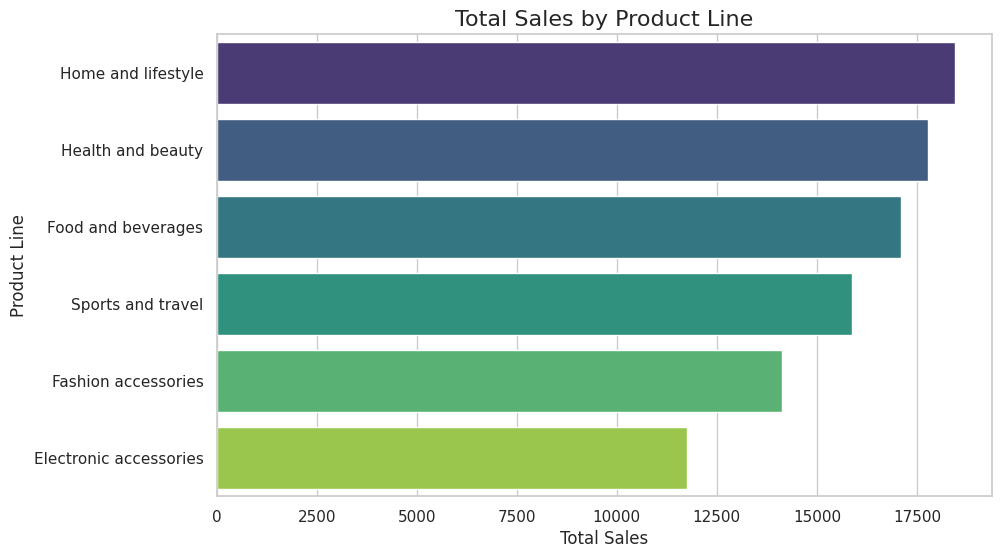

In [17]:
# Total Sales by Product Line

plt.figure(figsize=(10,6))

product_sales = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)

sns.barplot(
    x=product_sales.values,
    y=product_sales.index,
    palette="viridis"
)

plt.title("Total Sales by Product Line", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Product Line")

plt.show()

/tmp/ipykernel_1570/4231381514.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


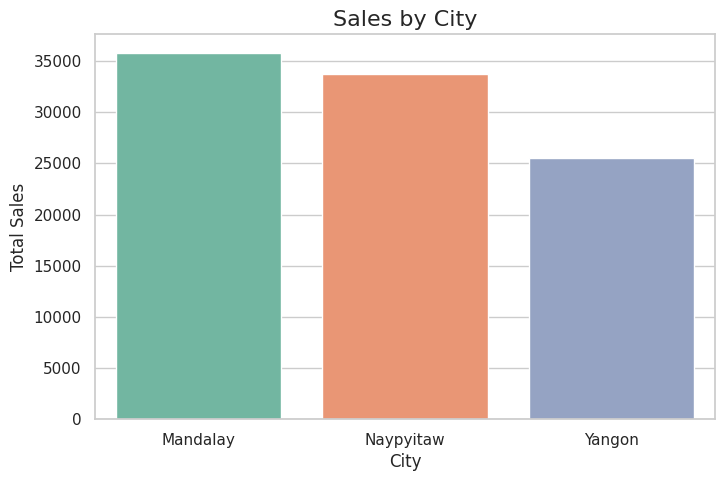

In [18]:
city_sales = df.groupby("City")["Total"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=city_sales.index,
    y=city_sales.values,
    palette="Set2"
)

plt.title("Sales by City", fontsize=16)
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.show()

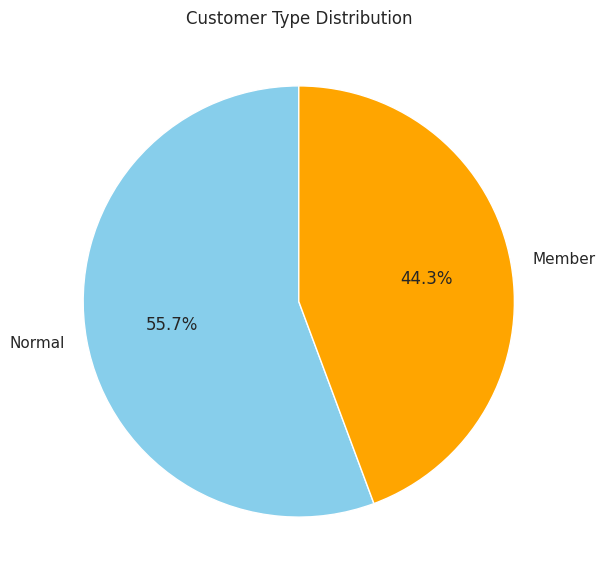

In [19]:
customer = df["Customer type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    customer,
    labels=customer.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue","orange"]
)

plt.title("Customer Type Distribution")

plt.show()

/tmp/ipykernel_1570/2971930528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


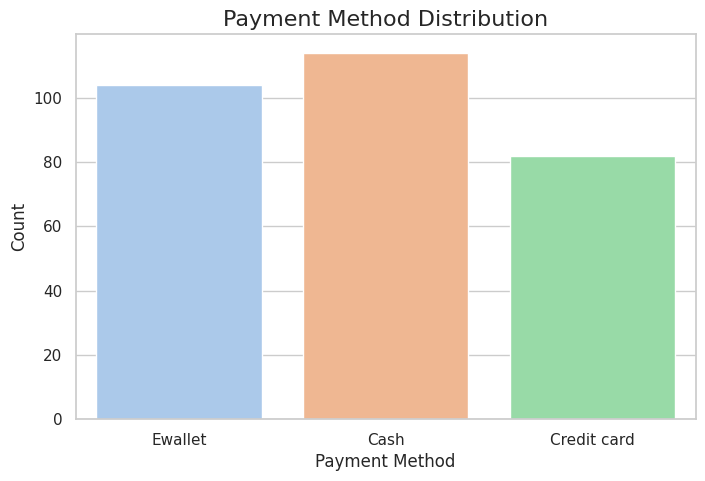

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Payment",
    palette="pastel"
)

plt.title("Payment Method Distribution", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.show()

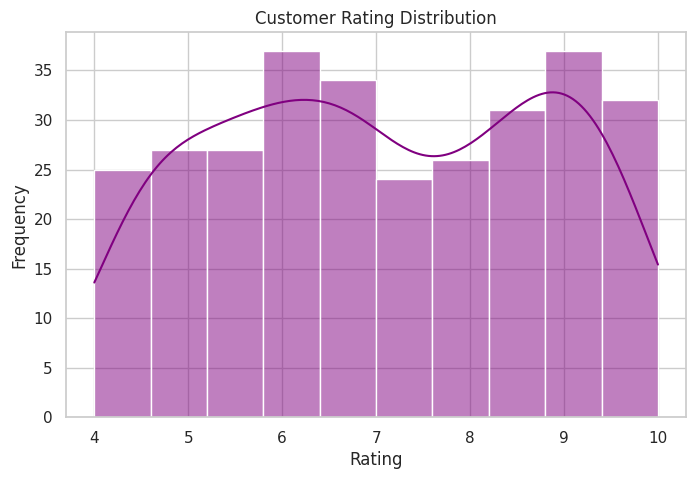

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=10,
    kde=True,
    color="purple"
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

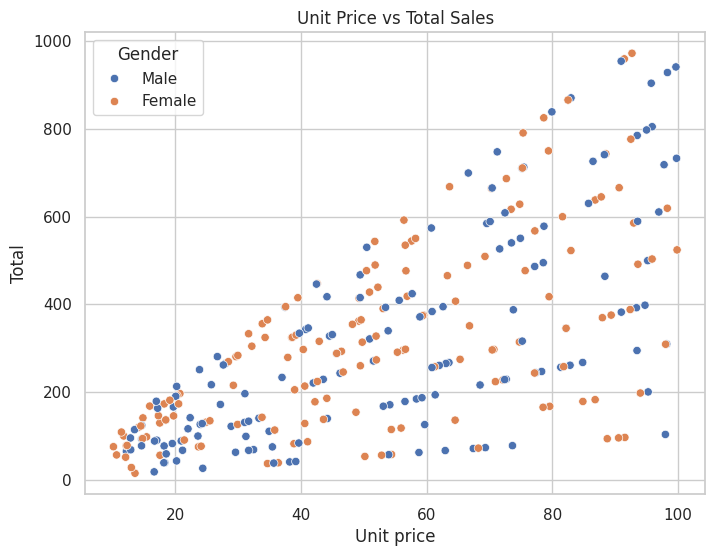

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Unit price",
    y="Total",
    hue="Gender"
)

plt.title("Unit Price vs Total Sales")

plt.show()

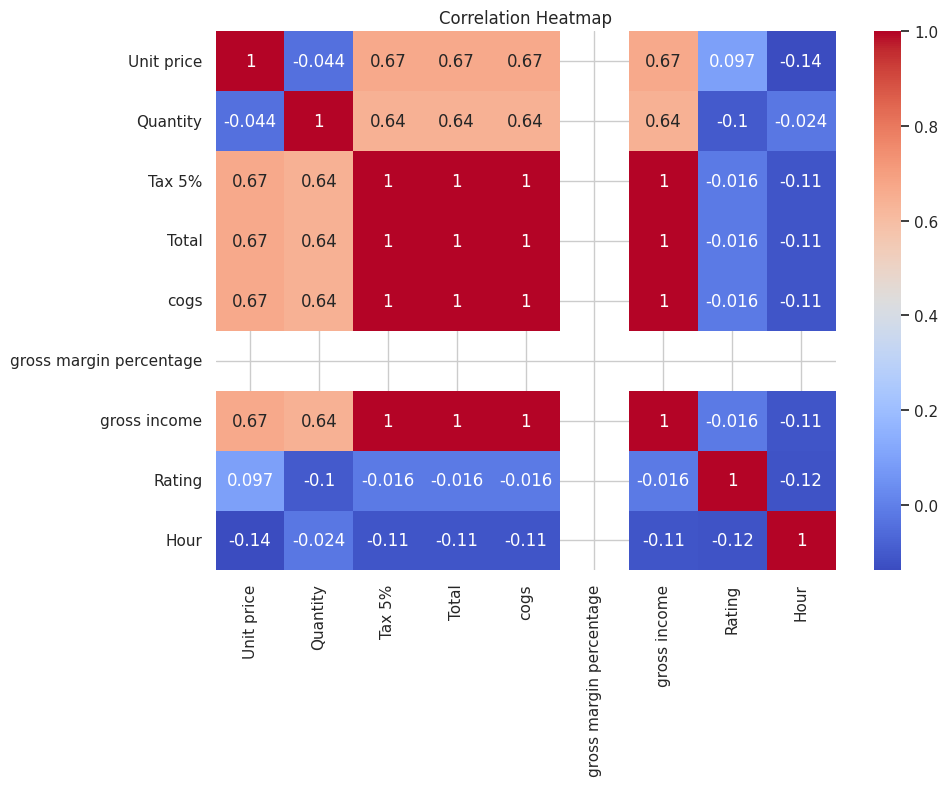

In [23]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

/tmp/ipykernel_1570/2782482144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


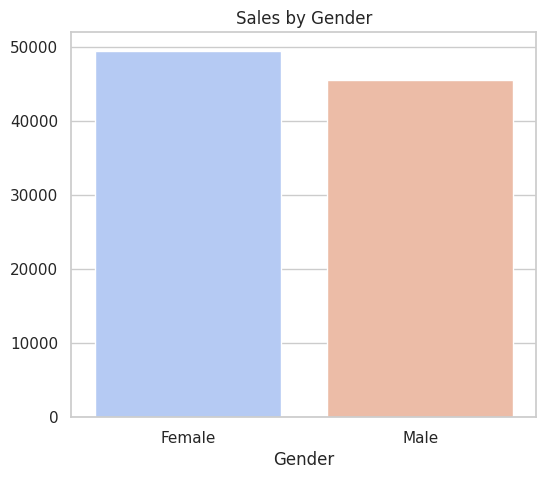

In [24]:
gender_sales = df.groupby("Gender")["Total"].sum()

plt.figure(figsize=(6,5))

sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values,
    palette="coolwarm"
)

plt.title("Sales by Gender")

plt.show()

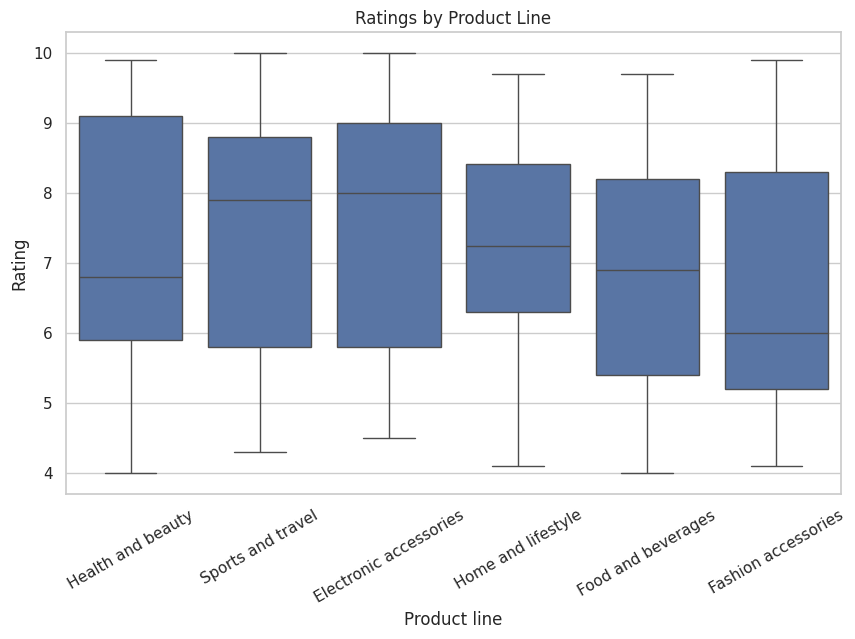

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Product line",
    y="Rating"
)

plt.xticks(rotation=30)

plt.title("Ratings by Product Line")

plt.show()

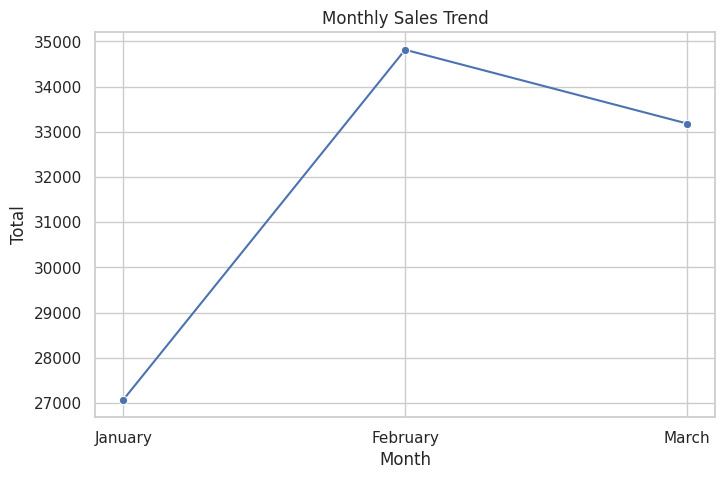

In [26]:
monthly_sales = df.groupby("Month")["Total"].sum().reset_index()

month_order = ["January", "February", "March"]
monthly_sales["Month"] = pd.Categorical(
    monthly_sales["Month"],
    categories=month_order,
    ordered=True
)
monthly_sales = monthly_sales.sort_values("Month")

plt.figure(figsize=(8,5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Total",
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.show()

/tmp/ipykernel_1570/3459437272.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1570/3459437272.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1570/3459437272.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


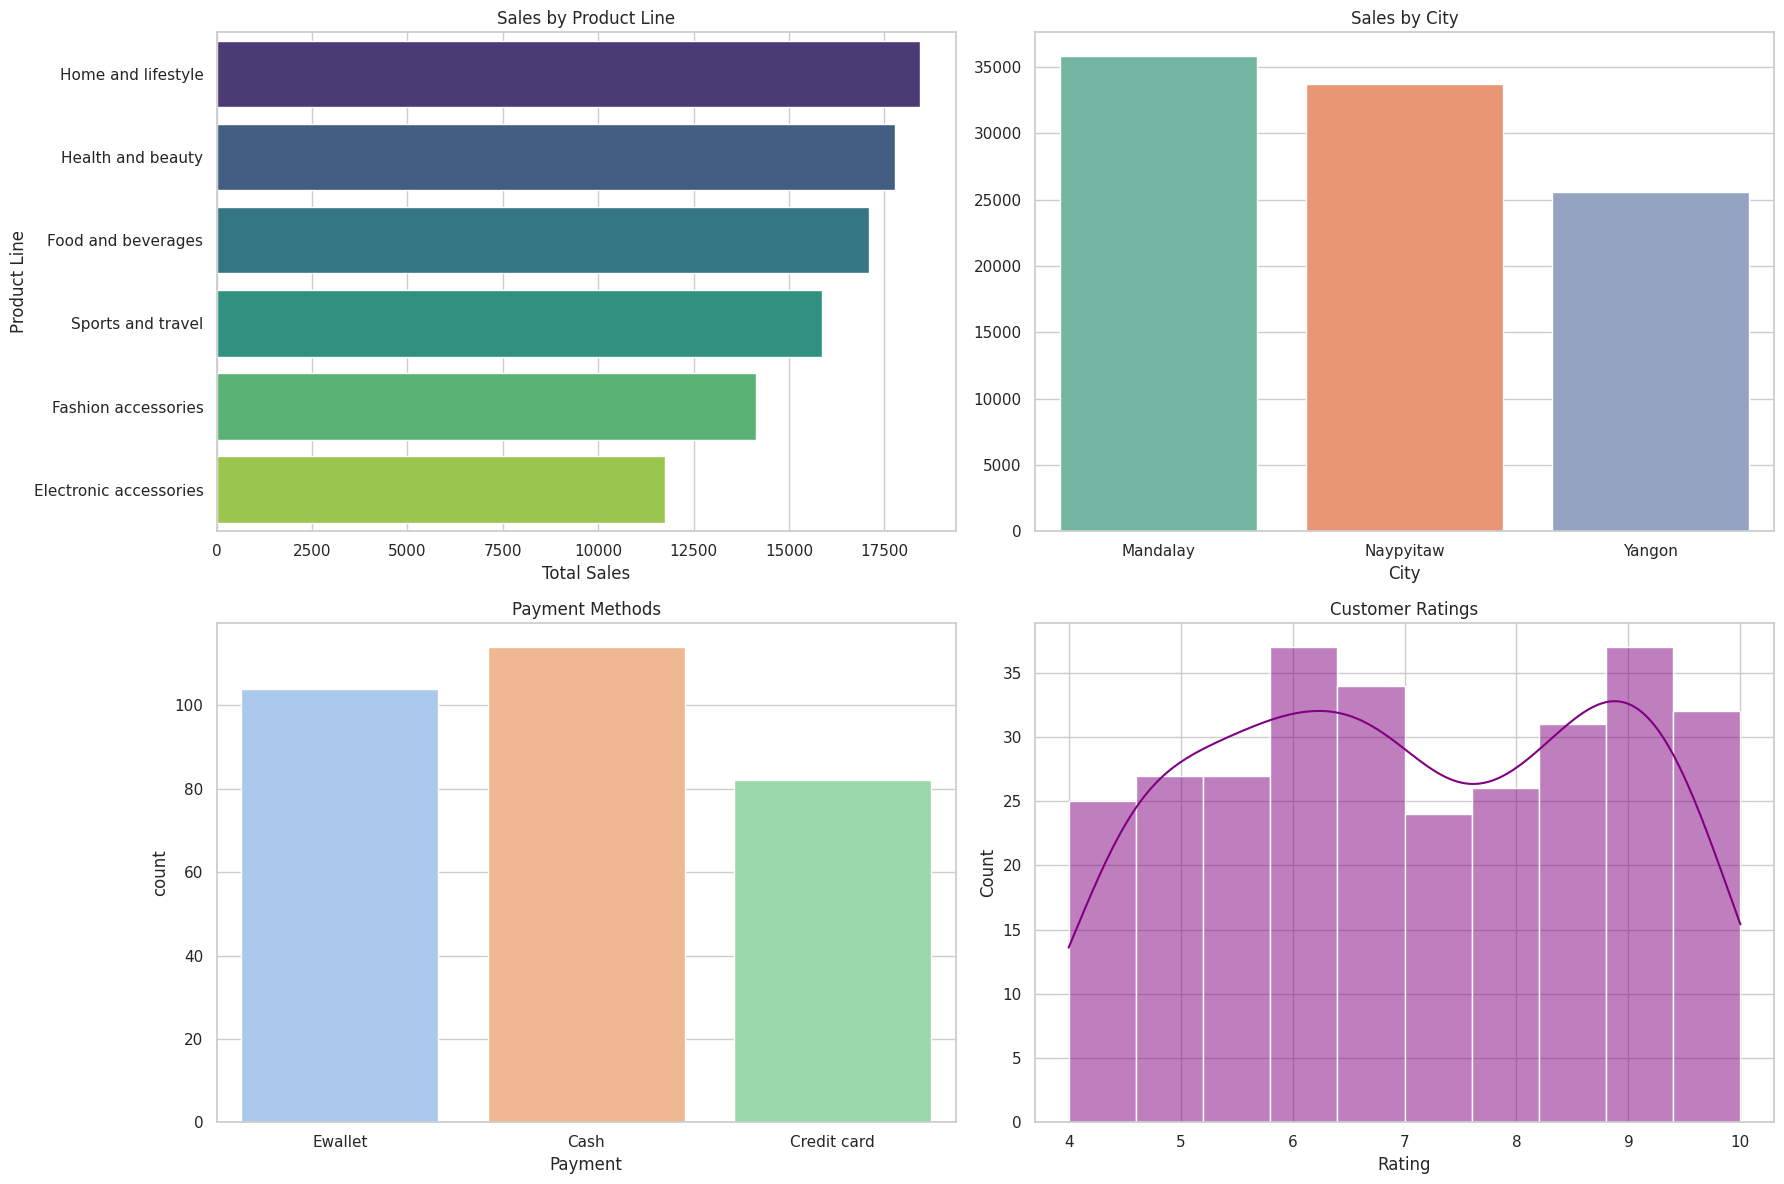

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Chart 1
product_sales = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)

sns.barplot(
    x=product_sales.values,
    y=product_sales.index,
    ax=axes[0,0],
    palette="viridis"
)

axes[0,0].set_title("Sales by Product Line")
axes[0,0].set_xlabel("Total Sales")
axes[0,0].set_ylabel("Product Line")

# Chart 2
city_sales = df.groupby("City")["Total"].sum()

sns.barplot(
    x=city_sales.index,
    y=city_sales.values,
    ax=axes[0,1],
    palette="Set2"
)

axes[0,1].set_title("Sales by City")

# Chart 3
sns.countplot(
    data=df,
    x="Payment",
    ax=axes[1,0],
    palette="pastel"
)

axes[1,0].set_title("Payment Methods")

# Chart 4
sns.histplot(
    df["Rating"],
    bins=10,
    kde=True,
    ax=axes[1,1],
    color="purple"
)

axes[1,1].set_title("Customer Ratings")

plt.tight_layout()

plt.show()

In [28]:
print("========== SUPERMARKET SALES DASHBOARD ==========")

print(f"Total Sales : ${df['Total'].sum():,.2f}")

print(f"Total Customers : {len(df)}")

print(f"Average Rating : {df['Rating'].mean():.2f}")

print(f"Average Unit Price : ${df['Unit price'].mean():.2f}")

print(f"Highest Sale : ${df['Total'].max():.2f}")

========== SUPERMARKET SALES DASHBOARD ==========
Total Sales : $95,072.64
Total Customers : 300
Average Rating : 7.06
Average Unit Price : $53.18
Highest Sale : $972.93


In [29]:
plt.savefig("sales_by_city.png", dpi=300, bbox_inches='tight')

<Figure size 1000x600 with 0 Axes>

In [30]:
plt.savefig("sales_by_product.png")

plt.savefig("payment_method.png")

plt.savefig("heatmap.png")

plt.savefig("dashboard.png")

<Figure size 1000x600 with 0 Axes>